___
# <center><a>Dyna-Q<a/>
___

In [46]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm import trange
from collections import defaultdict, Counter
from gymnasium.envs.toy_text.frozen_lake import generate_random_map


plt.style.use('ggplot')
np.random.seed(8)

___
## <center><a>Среда<a/>
___

Obseravtion space: Discrete(64)
Action space: Discrete(4)


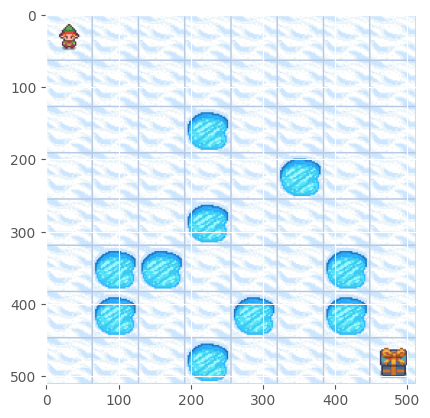

In [49]:
env = gym.make(
    id="FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=True,
    map_name="8x8"
    )
env.reset()
state_n = env.observation_space.n
act_n = env.action_space.n

print(f"Obseravtion space: {env.observation_space}")
print(f"Action space: {env.action_space}")

plt.imshow(env.render());

___
## <center><a>Q-learning Политика<a/>
___

- Таблица Q-значений [состояние, действие]

In [50]:
def get_qtable(env) -> np.ndarray:
    state_n = env.observation_space.n
    act_n = env.action_space.n
    qtable = np.zeros((state_n, act_n))
    return qtable

qtable = get_qtable(env)
qtable.shape

(64, 4)

- Действие с `максимальноым` Q-значением для текущего состояния

In [52]:
def get_max_value_action(qtable: np.ndarray, state: int) -> int:
    action = int(np.argmax(qtable[state, :]))
    return action

get_max_value_action(qtable, 0)

0

- Случайное действие для `исследования`

In [55]:
def get_random_action(env) -> int:
    action = int(env.action_space.sample())
    return action

get_random_action(env)

3

- `Epsilon-жадная` политика

In [57]:
def get_policy_action(env, qtable: np.ndarray, state: int, eps: float) -> int:
    if np.random.uniform(0, 1) > eps:
        action = get_max_value_action(qtable, state)
    else:
        action = get_random_action(env)
    return action

get_policy_action(env, qtable, 1, 0.1)

0

___
## <center><a> Обучение Q-learning<a/>
___

- $ \epsilon\in (0, 1)$ : max -> min 
    - Исследование -> Эксплуатация
- $Q(s_k, a_k) \leftarrow Q(s_k, a_k) + \alpha \cdot (r_k + \gamma \cdot max(Q(s_{k+1}, a_{k+1})) - Q(s_k, a_k))$

Q-learning Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Q-learning Episodes: 100%|██████████| 5000/5000 [00:16<00:00, 304.91it/s]


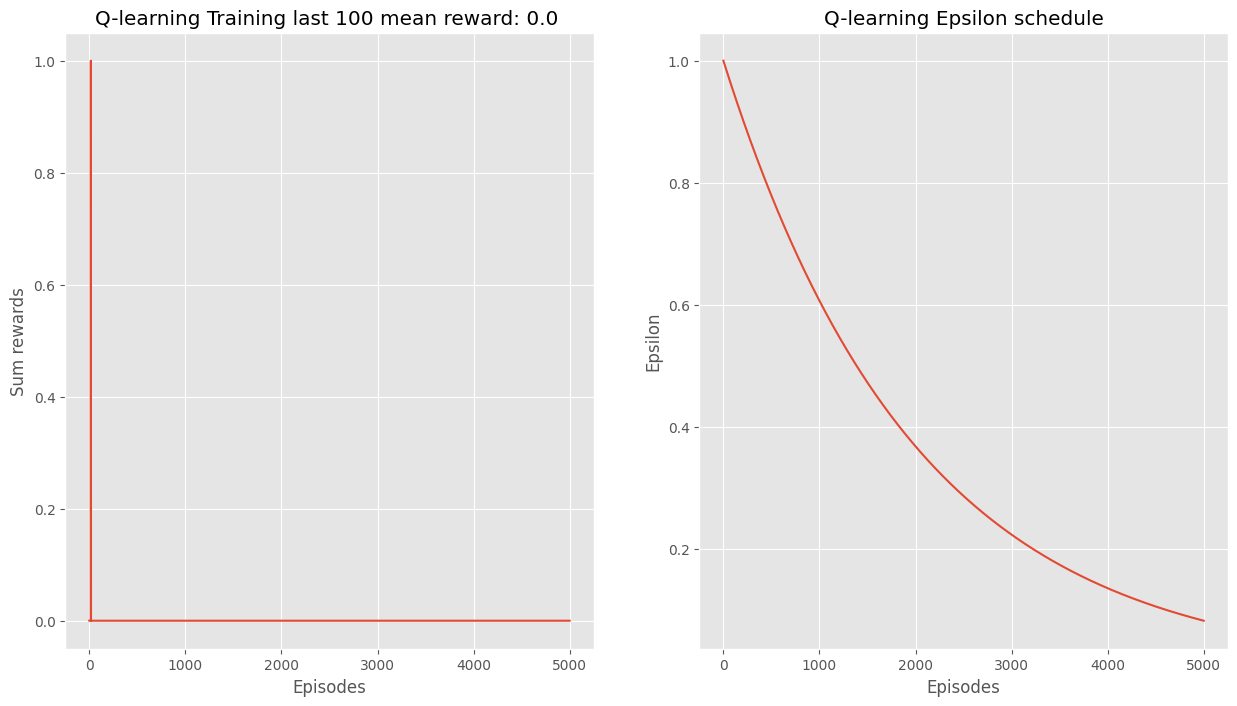

In [83]:
def train_algo(env, episodes_n, max_steps, eps_min, eps_decay, lr, gamma, reward_calc_n: int = 100):
    qtable = get_qtable(env)
    total_episodes_rewards = []
    total_eps = []
    for episode in trange(episodes_n, desc='Q-learning Episodes'):
        eps = max(eps_min, 1 * (eps_decay**episode))
        state, _ = env.reset(seed=8)

        episode_reward = 0
        for step in range(max_steps):
            action = get_policy_action(env, qtable, state, eps)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            qtable[state][action] = qtable[state][action] + lr * (reward + gamma * np.max(qtable[next_state])  * (1 - done) - qtable[state][action])
            episode_reward += reward

            if done:
                break
            state = next_state
        total_episodes_rewards.append(episode_reward)
        total_eps.append(eps)

    sum_reward = np.sum(total_episodes_rewards[-reward_calc_n:])
    mean_reward = np.mean(total_episodes_rewards[-reward_calc_n:])

    f, ax = plt.subplots(1,2, figsize=(15,8))
    ax[0].plot(total_episodes_rewards)
    ax[0].set_xlabel('Episodes')
    ax[0].set_ylabel('Sum rewards')
    ax[0].set_title(f"Q-learning Training last {reward_calc_n} mean reward: {mean_reward} ")

    ax[1].plot(total_eps)
    ax[1].set_xlabel('Episodes')
    ax[1].set_ylabel('Epsilon')
    ax[1].set_title(f"Q-learning Epsilon schedule")

    return qtable, mean_reward, sum_reward, total_episodes_rewards

trained_qtable, mean_reward, sum_reward, qtotal_episodes_rewards = train_algo(
    env=env,
    episodes_n=5000,
    max_steps=100,
    eps_min=0.01,
    eps_decay=0.9995,
    lr=0.1,
    gamma=0.99)

___
## <center><a>Оценка Q-learning<a/>
___
- Выбор действий с `максимальным Q-значениями` (эксплуатация)

Episodes: 100%|██████████| 300/300 [00:00<00:00, 529.67it/s]


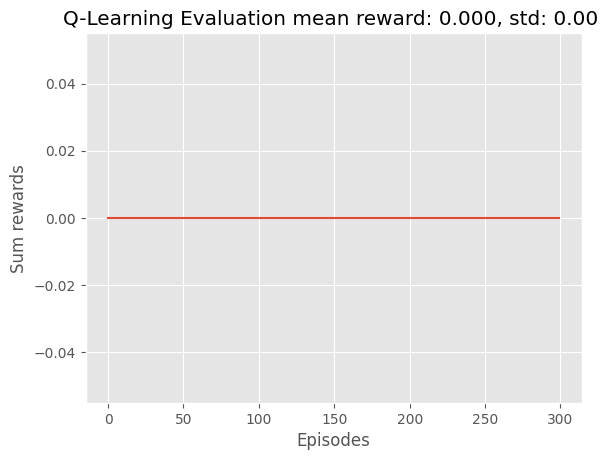

In [78]:
def evaluate_algo(env, episodes_n, max_steps, qtable, algo_name: str):
    env.reset(seed=1)
    total_episodes_rewards = []
    for episode in trange(episodes_n, desc='Episodes'):
        state, _ = env.reset()
        episode_reward = 0
        for step in range(max_steps):
            action = get_max_value_action(qtable, state)
            next_state, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            if truncated or terminated:
                break
            state = next_state
        total_episodes_rewards.append(episode_reward)
    std_reward = np.std(total_episodes_rewards)
    mean_reward = np.mean(total_episodes_rewards)
    plt.plot(total_episodes_rewards)
    plt.xlabel('Episodes')
    plt.ylabel('Sum rewards')
    plt.title(f"{algo_name} Evaluation mean reward: {mean_reward:.3f}, std: {std_reward:.2f} ")

    return mean_reward, sum_reward

mean_reward, sum_reward = evaluate_algo(
    env=env,
    episodes_n=300,
    max_steps=200,
    qtable=trained_qtable,
    algo_name='Q-Learning'
    )


___
## <center><a>Dyna-Q<a/>
___



In [79]:
def sample_stochastic_transition(model, state, action):
    outcomes_counter = model[(state, action)]
    outcomes = list(outcomes_counter.keys())
    counts = np.array(list(outcomes_counter.values()), dtype=np.float64)
    probs = counts / counts.sum()

    idx = np.random.choice(len(outcomes), p=probs)
    next_state, reward, done = outcomes[idx]
    return next_state, reward, done

___
## <center><a> Обучение Dyna-Q<a/>
___


Dyna-Q episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Dyna-Q episodes: 100%|██████████| 5000/5000 [05:17<00:00, 15.75it/s]


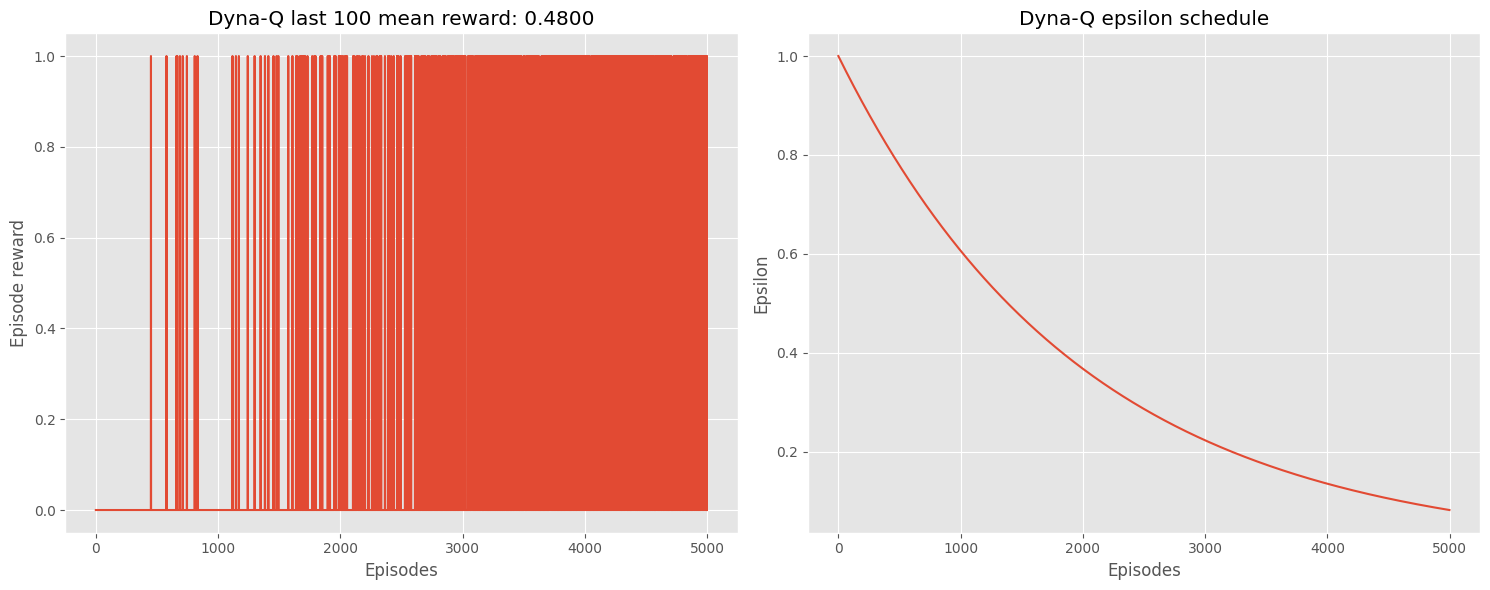

In [ ]:
def train_dyna_q_algo(
    env,
    episodes_n,
    max_steps,
    eps_min,
    eps_decay,
    lr,
    gamma,
    planning_steps=20,
    reward_calc_n: int = 100,
):
    qtable = get_qtable(env)
    model = defaultdict(Counter)
    seen_state_actions = []
    seen_state_actions_set = set()

    total_episodes_rewards = []
    total_eps = []

    for episode in trange(episodes_n, desc='Dyna-Q episodes'):
        eps = max(eps_min, 1.0 * (eps_decay ** episode))
        state, _ = env.reset(seed=episode)

        episode_reward = 0.0
        for step in range(max_steps):
            action = get_policy_action(env, qtable, state, eps)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            qtable[state, action] = qtable[state, action] + lr * (
                reward + gamma * np.max(qtable[next_state]) * (1 - done) - qtable[state, action]
            )

            key = (state, action)
            model[key][(next_state, reward, done)] += 1
            if key not in seen_state_actions_set:
                seen_state_actions_set.add(key)
                seen_state_actions.append(key)

            for _ in range(planning_steps):
                sim_state, sim_action = seen_state_actions[np.random.randint(len(seen_state_actions))]
                sim_next_state, sim_reward, sim_done = sample_stochastic_transition(model, sim_state, sim_action)

                qtable[sim_state, sim_action] = qtable[sim_state, sim_action] + lr * (
                    sim_reward + gamma * np.max(qtable[sim_next_state]) * (1 - sim_done) - qtable[sim_state, sim_action]
                )

            episode_reward += reward

            if done:
                break
            state = next_state

        total_episodes_rewards.append(episode_reward)
        total_eps.append(eps)

    sum_reward = np.sum(total_episodes_rewards[-reward_calc_n:])
    mean_reward = np.mean(total_episodes_rewards[-reward_calc_n:])

    f, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].plot(total_episodes_rewards)
    ax[0].set_xlabel('Episodes')
    ax[0].set_ylabel('Episode reward')
    ax[0].set_title(f'Dyna-Q last {reward_calc_n} mean reward: {mean_reward:.4f}')

    ax[1].plot(total_eps)
    ax[1].set_xlabel('Episodes')
    ax[1].set_ylabel('Epsilon')
    ax[1].set_title('Dyna-Q epsilon schedule')

    plt.tight_layout()
    return qtable, model, mean_reward, sum_reward, np.array(total_episodes_rewards, dtype=np.float64)

trained_dyna_qtable, dyna_model, dyna_mean_reward, dyna_sum_reward, dyna_train_rewards = train_dyna_q_algo(
    env=env,
    episodes_n=5000,
    max_steps=200,
    eps_min=0.01,
    eps_decay=0.9995,
    lr=0.1,
    gamma=0.99,
    planning_steps=20,
)


___
## <center><a>Оценка Dyna-Q<a/>
___
- Выбор действий с `максимальным Q-значениями` (эксплуатация)

Episodes: 100%|██████████| 1000/1000 [00:01<00:00, 815.73it/s]


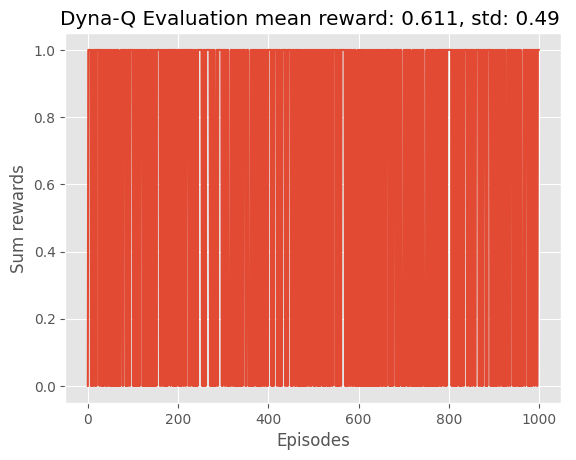

In [81]:
dyna_eval_mean_reward, dyna_eval_sum_reward = evaluate_algo(
    env=env,
    episodes_n=1000,
    max_steps=100,
    qtable=trained_dyna_qtable,
    algo_name='Dyna-Q'
)

___
## <center><a>Сравнение Dyna-Q и Q-Learning<a/>
___

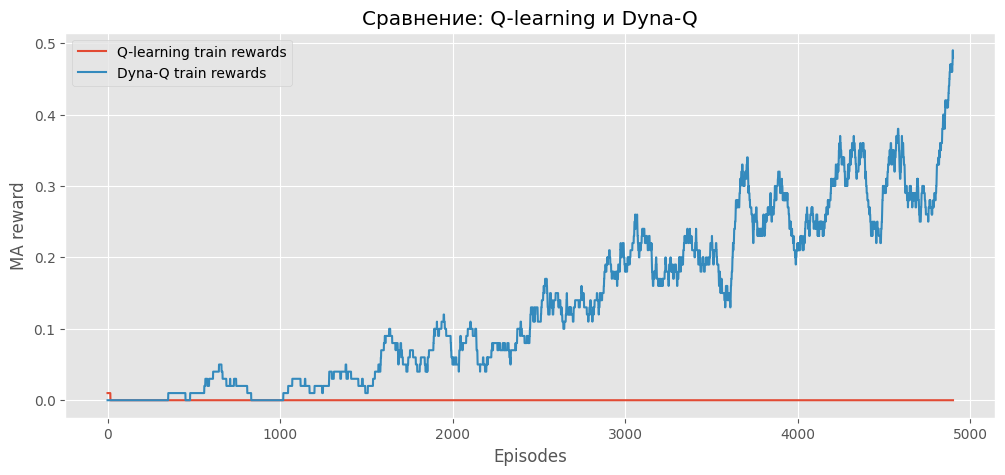

In [ ]:

def moving_average(x, window=100):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(x, kernel, mode='valid')


plt.figure(figsize=(12, 5))
plt.plot(moving_average(qtotal_episodes_rewards, 100), label='Q-learning train rewards')
plt.plot(moving_average(dyna_train_rewards, 100), label='Dyna-Q train rewards')
plt.xlabel('Episodes')
plt.ylabel('MA reward')
plt.title('Сравнение: Q-learning и Dyna-Q')
plt.legend()
plt.show()